# CASE 2: Breaking RSA

You are working for the Norwegian Intelligence Service (Etterretningstjeneste) and have
been asked by a senior cybersecurity analyst to demonstrate how RSA encryption can be
broken with a quantum computer and Shor’s algorithm. The analyst is also wondering why
RSA encryption cannot already be broken today with Shor’s algorithm? What are the
major limitations and or bottlenecks?

### What is RSA?

RSA is a type of public encryption that uses a private and a public key. Only the corresponding private key to a public can decrypt the encrypted message. RSA is based on the difficulty of factoring large composite numbers, which are made up of two large prime numbers.

### Python Imports

In [1]:

import numpy as np
from numpy.random import randint
import pandas as pd
import random 
from math import gcd

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
import matplotlib.pyplot as plt

from fractions import Fraction

### RSA Encryption

In [2]:

def gcd_euclid(a,b):
    assert a >= 0 and b >= 0
    while b!= 0:
        r = a%b
        a,b = b,r
    return a

def gcd_euclid_extended(a,b):
    progress = []
    assert a >= 0 and b >= 0

    #Euclid's algorithm keeping track of divisors "d"
    while b!= 0:
        r = a%b
        d = a//b
        progress.append((a,b,d,r))
        a,b = b,r

    progress = pd.DataFrame(progress,
                            columns = ['a','b','d','r'])
    
    #Extended Euclid's algorithm
    d_nm1 = progress['d'].iloc[-2]
    x,y = 1,-d_nm1

    extended_progress = []
    extended_progress.append([x,y,-d_nm1])
    
    for i in range(len(progress)-2):
        md = -1*progress['d'].iloc[-i-3]
        x, y = y, x + y *md 
        extended_progress.append([x, y, md])

    extended_progress = pd.DataFrame(extended_progress, columns = ['x','y','-d'])
    return a, progress, x, y, extended_progress

def decrypt_RSA(private_key, encrypted_message):
    d, n = private_key
    return pow(encrypted_message, int(d), int(n))

def encrypt_RSA(public_key, message):
    e, n = public_key
    return pow(message, int(e), int(n))

### How do we use Shor's algortihm to break RSA?

Shor's algorithm is designed to efficiently factorize large composite numbers. Within quantum computing this means that it can speed up the process of finding the prime numbers of an integer(which is what RSA is based off).

### Shor's algortihm as a quantum circuit 

Building block for the quantum circuit we are going to build

In [3]:
def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,4,7,8,11,13]:
        raise ValueError("'a' must be 2,4,7,8,11 or 13")
    U = QuantumCircuit(4)
    for _iteration in range(power):
        if a in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

Import of the QFT circuit 

In [4]:
def qft_dagger(n):
    """n-qubit QFTdagger the first n qubits in circ"""
    qc = QuantumCircuit(n)
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

With the building blocks from above we can now create the quantum circuit

In [5]:
N_count = 8
a = 7

qc= QuantumCircuit(N_count + 4, N_count)

for q in range(N_count):
    qc.h(q)

qc.x(N_count)

for q in range(N_count):
    qc.append(c_amod15(a, 2**q),
            [q] + [i+N_count for i in range(4)])



qc.append(qft_dagger(N_count), range(N_count))

qc.measure(range(N_count), range(N_count))
qc.draw(fold=-1)  

┌───┐                                                                                                                             ┌───────┐┌─┐                     
 q_0: ┤ H ├───────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0      ├┤M├─────────────────────
      ├───┤       │                                                                                                                     │       │└╥┘┌─┐                  
 q_1: ┤ H ├───────┼──────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────┤1      ├─╫─┤M├──────────────────
      ├───┤       │              │                                                                                                      │       │ ║ └╥┘┌─┐               
 q_2: ┤ H ├───────┼──────────────┼──────────────■───────────────────────────────────────────────────────────────────────────────────────┤2      ├─╫──╫─┤M├───────────────
      ├───┤       │              │              │                                                                                       │       │ ║  ║ └╥┘┌─┐            
 q_3: ┤ H ├───────┼──────────────┼──────────────┼──────────────■────────────────────────────────────────────────────────────────────────┤3      ├─╫──╫──╫─┤M├────────────
      ├───┤       │              │              │              │                                                                        │  QFT† │ ║  ║  ║ └╥┘┌─┐         
 q_4: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────■─────────────────────────────────────────────────────────┤4      ├─╫──╫──╫──╫─┤M├─────────
      ├───┤       │              │              │              │              │                                                         │       │ ║  ║  ║  ║ └╥┘┌─┐      
 q_5: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────■─────────────────────────────────────────┤5      ├─╫──╫──╫──╫──╫─┤M├──────
      ├───┤       │              │              │              │              │               │                                         │       │ ║  ║  ║  ║  ║ └╥┘┌─┐   
 q_6: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────■─────────────────────────┤6      ├─╫──╫──╫──╫──╫──╫─┤M├───
      ├───┤       │              │              │              │              │               │               │                         │       │ ║  ║  ║  ║  ║  ║ └╥┘┌─┐
 q_7: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────┼────────────────■────────┤7      ├─╫──╫──╫──╫──╫──╫──╫─┤M├
      ├───┤┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴───────┐┌──────┴───────┐┌──────┴───────┐┌───────┴───────┐└───────┘ ║  ║  ║  ║  ║  ║  ║ └╥┘
 q_8: ┤ X ├┤0            ├┤0            ├┤0            ├┤0            ├┤0             ├┤0             ├┤0             ├┤0              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
      └───┘│             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
 q_9: ─────┤1            ├┤1            ├┤1            ├┤1            ├┤1             ├┤1             ├┤1             ├┤1              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │  7^1 mod 15 ││  7^2 mod 15 ││  7^4 mod 15 ││  7^8 mod 15 ││  7^16 mod 15 ││  7^32 mod 15 ││  7^64 mod 15 ││  7^128 mod 15 │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_10: ─────┤2            ├┤2            ├┤2            ├┤2            ├┤2             ├┤2             ├┤2             ├┤2              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_11: ─────┤3            ├┤3            ├┤3            ├┤3            ├┤3             ├┤3       

The result from above measured:

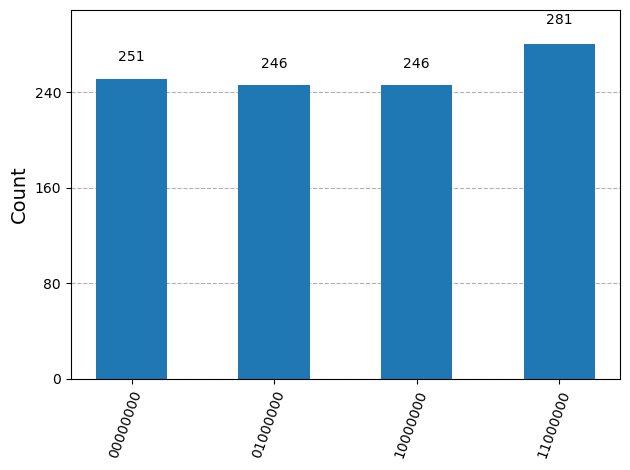

In [6]:
simulator = AerSimulator()
t_qc = transpile(qc, simulator)
job = simulator.run(t_qc, shots=1024)
result = job.result()
counts = result.get_counts()

plot_histogram(counts)

Since we now have 8 qubits from the quantum circuit we can see the result corresponds to measured phase of:

In [39]:
rows, measured_phase = [], []
for output in counts:
    decimal = int(output, 2)
    phase = decimal/(2**N_count)
    measured_phase.append(phase)
    rows.append([f"{output}bin = {decimal:>3}(dec)",
                f"{decimal}/{2**N_count} = {phase:.2f}"])
headers = ["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

          Register Output           Phase
0  01000000bin =  64(dec)   64/256 = 0.25
1  00000000bin =   0(dec)    0/256 = 0.00
2  11000000bin = 192(dec)  192/256 = 0.75
3  10000000bin = 128(dec)  128/256 = 0.50


In [40]:
Fraction(0.666)

Fraction(5998794703657501, 9007199254740992)

In [41]:
Fraction(0.666).limit_denominator(15)

Fraction(2, 3)

In [42]:
rows = []

for phase in measured_phase:
    frac = Fraction(phase).limit_denominator(15)
    rows.append([phase,
                f"{frac.numerator}/{frac.denominator}",
                {frac.denominator}])

headers = ["phase", "Fraction", "guess for r"]
df=pd.DataFrame(rows, columns=headers)
print(df)

   phase Fraction guess for r
0   0.25      1/4         {4}
1   0.00      0/1         {1}
2   0.75      3/4         {4}
3   0.50      1/2         {2}


### How does Shor's algortihm works?

In [43]:
# For this demo i will use 15 as factor 
N = 15

# Step 1: Select a random seed number a
def shor_step1(N):
    np.random.seed(1)
    a = randint(2,15)
print(a)



7


In [44]:
# Check that it isn't already a non-trivial factor of N
gcd(a, N)

1

For step 2 of Shor's algorithm which is to find the order of A for a = 7 and N = 15. The phase we will measure is s/r where: 
$$
a^r \bmod N \;=\; 1
$$

And s is a random integer between 0 and r-1.

In [45]:
# Step 2: Find the order of a
def shor_step2(a):
    N_count = 8
    qc = QuantumCircuit(4+N_count, N_count)
    for q in range(N_count):
        qc.h(q)
    qc.x(N_count)
    for q in range(N_count):
        qc.append(c_amod15(a, 2**q),
                  [q] + [i+N_count for i in range(4)])
    qc.append(qft_dagger(N_count), range(N_count))
    qc.measure(range(N_count), range(N_count))

    simulator = AerSimulator()
    t_qc = transpile(qc, simulator)
    job = simulator.run(t_qc, shots=1, memory=True)
    result = job.result()
    readings = result.get_memory()
    bitstr = readings[0]
    print("Register reading: " + bitstr)
    phase = int(bitstr, 2) / (2 ** N_count)
    print(f"Corresponding phase: {phase}")

    return phase

From this phase we can find a guess for r

In [49]:
phase = shor_step2(a)
Fraction(phase).limit_denominator(15)

Register reading: 10000000
Corresponding phase: 0.5


Fraction(1, 2)

In [50]:
frac = Fraction(phase).limit_denominator(15)
s, r = frac.numerator, frac.denominator
print (r)

2


Now we have found r, we might be able to use this in step 3 of Shor's algortihm with using this to find a Factor of N since:
$$
a^r \bmod N \;=\; 1
$$
then:
$$
a^r -1 \bmod N \;=\; 0
$$
Which means N must divide       . And if r is also even then we can write:
$$
a^r - 1 \;=\; \bigl(a^{\frac{r}{2}} - 1\bigr)\bigl(a^{\frac{r}{2}} + 1\bigr)
$$
if r is not even we cannot go further and have to go back to step 1 of the algortihm. There is then a high probability that the greatest common divisor of N and either $ a^{\frac{r}{2}} - 1$ ,or $ a^{\frac{r}{2}} + 1$ is a proper factor of N.




In [52]:
guesses = [gcd(a**(r//2)-1, N), gcd(a**(r//2)+1, N)]
print(guesses)

[3, 1]


In [53]:
a = 7
FACTOR_FOUND = False
ATTEMPT = 0
while not FACTOR_FOUND:
    ATTEMPT += 1
    print(f"\nAttempt {ATTEMPT}:")
    phase = shor_step2(a)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    print(f"Result: r = {r}")
    if phase !=0:
        guesses = [gcd(a**(r//2)-1, N), gcd(a**(r//2)+1, N)]
        print(f"Guessed Factors: {guesses[0]} and {guesses[1]}")
        for guess in guesses:
            if guess not in [1,N] and (N % guess) == 0:
                print(f"*** Non-Trivial factor found: {guess} ***")
                FACTOR_FOUND = True


Attempt 1:
Register reading: 00000000
Corresponding phase: 0.0
Result: r = 1

Attempt 2:
Register reading: 00000000
Corresponding phase: 0.0
Result: r = 1

Attempt 3:
Register reading: 01000000
Corresponding phase: 0.25
Result: r = 4
Guessed Factors: 3 and 5
*** Non-Trivial factor found: 3 ***
*** Non-Trivial factor found: 5 ***


In [128]:
assert(3 in guesses) or (5 in guesses)

### Shor's algortihm demo - Breaking RSA

In [23]:
def classical_postprocess(a, N, r):
    if r % 2 !=0:
        raise ValueError("R has to be a even number")
    apow = pow(a, r // 2, N)
    if apow == N - 1:
        raise ValueError("a^(r/2) ≡ -1 mod N. try new a")
    p = gcd_euclid(apow - 1, N)
    q = gcd_euclid(apow + 1, N)
    return p, q


RSA instance

In [24]:
p = 3
q = 5
N = p * q
phi = (p - 1) * (q - 1)
e = 7
d = pow(e, -1, phi)

print(f"p = {p}")
print(f"q = {q}")
print(f"N = {N}")
print(f"phi = {phi}")
print(f"public e = {e}")
print(f"private d = {d} because {e}*{d} =1 mod {phi}")

m = 11
c = pow(m, e, N)
print(f"\n Original message m = {m}")
print(f"\n Encrypted message c = {c} (c = {m}^{e} mod {N})")

p = 3
q = 5
N = 15
phi = 8
public e = 7
private d = 7 because 7*7 =1 mod 8

 Original message m = 11

 Encrypted message c = 11 (c = 11^7 mod 15)


In [54]:
def shor_classical_preprocess(a, N):
    g = gcd_euclid(a, N)
    if g > 1:
        return None, g
    else:
        return a, None

a_val, factor_without_quantum = shor_classical_preprocess(a, N)
if factor_without_quantum is not None:
    print(f"Found factor directly: gcd({a},{N}) = {factor_without_quantum}")
else:
    print(f"a = {a_val} is relative prime to N. Continuing...")


a = 7 is relative prime to N. Continuing...


In [55]:
def quantum_order_finding(a, N, DemoN_Count):
    return 4


r = quantum_order_finding(a, N, DemoN_Count=4)
print(f"Estimated period r = {r}")

Estimated period r = 4


This is correct since:
$$
7^4 \;\equiv\; 2401 \;\equiv\; 1 \pmod{15}.
$$

In [56]:
p_found, q_found = classical_postprocess(a, N, r)
print(f"Shor found: p = {p_found} and q = {q_found}")

Shor found: p = 3 and q = 5


With this information we can reconstruct the message, and find the content of the decrypted message 

In [57]:
phi_rebuilt = (p_found -1) * (q_found - 1)
d_rebuilt = pow(e, -1, phi_rebuilt)

print(f"Reconstructed phi = {phi_rebuilt}")
print(f"Recounstructed d = {d_rebuilt}")

m_decrypted = pow(c, d_rebuilt, N)
print(f"Decrypted m message = {m_decrypted}")

Reconstructed phi = 8
Recounstructed d = 7
Decrypted m message = 11


With this demo we can see that Shor's algorithm has found the values of p=3 and q=5 which we can use to recontruct the private key (d = 7, N = 15) and decrypt c = 11^7 back to m= 11. this shows us that Shor's algortihm can break RSA in theory. 

### Why  Can't we break RSA Encryption today?

If we were to try and break a typical modern RSA implementation that uses an n with 4096 bits with brute force, and the help of The Prime Number Theorem this is what it would look like:


T ≈ Number of primes × Time per test

$$
T \;\approx\; \frac{2^{2048}}{\ln\bigl(2^{2048}\bigr)} \times 10^{9}\,\text{seconds}
\;=\; \frac{2^{2048}}{2048\,\ln(2)} \times 10^{9}\,\text{seconds}
\;\approx\; \frac{2^{2048}}{2^{1420}} \times 10^{9}\,\text{seconds}.
$$

Let’s approximate all the numbers using base 2 to make them comparable:

$$
\frac{2^{2048}}{2^{1420}} \times 10^{9}\,\text{seconds}
\;\approx\; \frac{2^{2048}}{2^{11}} \times 10^{9}\,\text{seconds}
\;=\; 2^{2037} \times 10^{9}\,\text{seconds}
\;=\; 2^{1956}\,\text{seconds}.
$$


Converting into years gives us:

$$
21986\ \text{seconds} \;\times\; \frac{1\ \text{year}}{31\,536\,000\ \text{seconds}}
\;\approx\; \frac{21986}{31\,536\,000}\ \text{years}
\;\approx\; \frac{21986}{225}\ \text{years}
\;=\; 2^{1961}\ \text{years}.
$$

This is quite a big number because when comparing the age of the universe in base 2 we get $ 2^{34} $

All of the above is done with a classical computer trying to break RSA, but what if we were to use Shor's algorithm and a quantum computer?

In the paper of Craig Gidney and Martin Ekerå "How to factor 2048 bit RSA in 8 hours using 20 million noisy qubits" from 2021 they estimate that breaking modern day RSA encryption would need 20 000 logical qubits or around 20 million noisy qubits. They also imply that they would be able to do this at a runtime around 7 hours(assuming only one run of the quantum part of the algortihm is needed). (https://arxiv.org/pdf/1905.09749) 


### Conclusion

Conclusion of my findings and thoughts:


As of right now RSA is safe since it is not possible to use shor's algortihm in practice. This demo of Shor's algortihm shows how it can be utizlized to break encryption and in the future can help make crack them quicker then what a digital computer is able to as of now. The quantum computers we have today are not big enough and too noisy to be able to perform in reality. IBM who are big within the devlopment of quantum computers have  1 121 qubits in their qunatum processor Condor.

Think of encryption as a lock on your house. 




